Task

* accuracy and loss graph
* confusion matrix
* remove 2nd conv and then polling (2nd model)
* remove dense(128) layer (3rd model)


In [1]:
import base_model as bm

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9506 - loss: 0.1643 - val_accuracy: 0.9797 - val_loss: 0.0705
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9845 - loss: 0.0521 - val_accuracy: 0.9895 - val_loss: 0.0374
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.9886 - loss: 0.0367 - val_accuracy: 0.9887 - val_loss: 0.0393
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9918 - loss: 0.0256 - val_accuracy: 0.9910 - val_loss: 0.0356
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.9927 - loss: 0.0211 - val_accuracy: 0.9900 - val_loss: 0.0311
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9953 - loss: 0.0146 - val_accuracy: 0.9875 - val_loss: 0.0409
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9961 - loss: 0.0117 - val_accuracy: 0.9873 - val_loss: 0.0468
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.9964 - loss: 0.0105 - 

## How we are getting that many parameters
1. conv2d -> (32x3x3) -> 288W + 32B => 320 <- total parameters
2. conv2d -> (64x32)-> 2048 x (3x3) --> 18432W + 64B -> 18496 <- total parameters [over all seen -> (32x(64x3x3)+64)]
3. 1600 x 128 => 204800W + 128B => 204928 <- total parameters
4. 128 x 10 -> 1280 + 10 => 1290 <- total parameters

In [2]:
model2 = bm.Sequential([
    bm.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    bm.MaxPooling2D((2,2)),

    bm.Flatten(),

    bm.Dense(128, activation='relu'),
    bm.Dense(10, activation='softmax')
])

model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model3 = bm.Sequential([
    bm.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    bm.MaxPooling2D((2,2)),

    bm.Flatten(),

    bm.Dense(10, activation='softmax')
])
model3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model2.fit(bm.X_train_cnn, bm.y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose=0)

history2 = model3.fit(bm.X_train_cnn, bm.y_train,
          epochs=10,
          batch_size=64,
          validation_split=0.1,
          verbose=0)

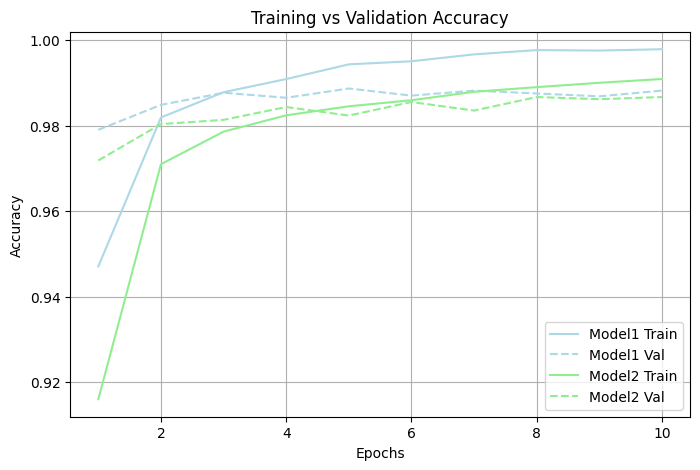

In [5]:
import matplotlib.pyplot as plt

# Accuracy values
acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']

epochs = range(1, len(acc1) + 1)

plt.figure(figsize=(8,5))

# Model 1
plt.plot(epochs, acc1, color='lightblue', linestyle='-', label='Model1 Train')
plt.plot(epochs, val_acc1, color='lightblue', linestyle='--', label='Model1 Val')

# Model 2
plt.plot(epochs, acc2, color='lightgreen', linestyle='-', label='Model2 Train')
plt.plot(epochs, val_acc2, color='lightgreen', linestyle='--', label='Model2 Val')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# same validation split
X_train, X_val, y_train, y_val = train_test_split(
    bm.X_train_cnn, bm.y_train, test_size=0.1, random_state=42
)

# predictions
y_pred1 = model2.predict(X_val)
y_pred2 = model3.predict(X_val)

# probabilities -> class labels
y_pred1 = y_pred1.argmax(axis=1)
y_pred2 = y_pred2.argmax(axis=1)

# true labels (already 1D)
y_true = y_val

# confusion matrices
cm1 = confusion_matrix(y_true, y_pred1)
cm2 = confusion_matrix(y_true, y_pred2)

print("Model1 Confusion Matrix:")
print(cm1)

print("\nModel2 Confusion Matrix:")
print(cm2)

188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Model1 Confusion Matrix:
[[623   0   0   0   0   0   1   0   0   0]
 [  0 653   1   0   0   0   0   0   0   0]
 [  0   0 572   0   0   0   0   0   0   0]
 [  0   0   0 588   0   1   0   0   0   0]
 [  0   0   0   0 580   0   0   0   0   0]
 [  1   0   0   0   0 550   0   0   0   0]
 [  0   0   0   0   0   0 580   0   0   0]
 [  0   0   0   0   0   0   0 632   1   0]
 [  0   0   0   0   1   1   0   0 583   0]
 [  0   0   0   0   2   0   0   1   0 629]]

Model2 Confusion Matrix:
[[619   0   0   0   0   2   1   0   2   0]
 [  0 652   0   1   0   0   0   0   1   0]
 [  0   0 569   0   0   0   0   2   0   1]
 [  0   0   2 583   0   3   0   1   0   0]
 [  1   0   0   0 575   0   0   0   1   3]
 [  1   0   0   1   0 548   0   0   1   0]
 [  0   0   0   0   0   1 576   0   3   0]
 [  0   0   2   1   0   0   0 629   1   0]
 [  1   0   3   0   1   0   0   0 580   0]
 [  0   0   0   0   1   0   0   1   1 629]]


# Now test on Real data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


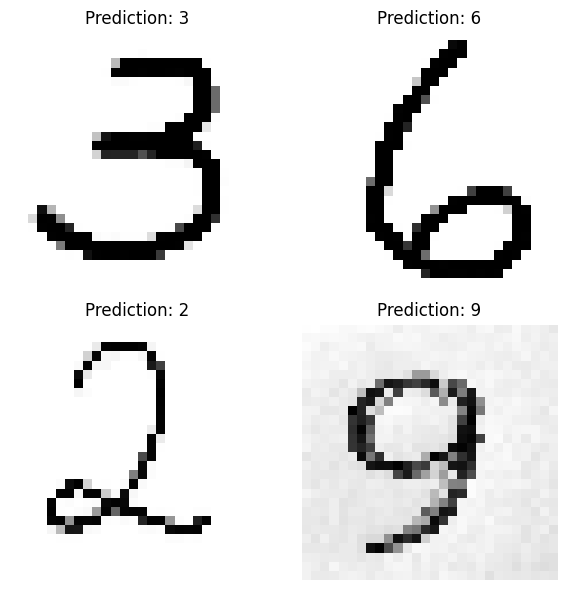

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

files = ["f1.png", "f2.png", "f3.png", "f4.jpeg"]

images = []
orig_images = []

for f in files:
    img = cv2.imread(f, 0)          # grayscale
    img = cv2.resize(img, (28,28))

    orig_images.append(img)

    img = img / 255.0               # normalize
    img = 1 - img                   # invert
    images.append(img)

# CNN input shape
images = np.array(images).reshape(-1,28,28,1)

pred = bm.model.predict(images)
pred_class = np.argmax(pred, axis=1)

# ---- 2 x 2 subplot ----
plt.figure(figsize=(6,6))

for i in range(len(files)):
    plt.subplot(2,2,i+1)
    plt.imshow(orig_images[i], cmap="gray")
    plt.title(f"Prediction: {pred_class[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()